In [6]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
# Load your dataset (same one used earlier)
df = pd.read_csv("final.csv")

# Feature list (IMPORTANT: match your model exactly)
features = [
    'NDVI','EVI','NDMI','NDWI',
    'LST','Rainfall','Rainfall_lag1'
]

In [8]:
df = df.sort_values(by=["point_id", "Year", "Month"]).reset_index(drop=True)

In [9]:
model = joblib.load("Best_model.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HalvingGridSearchCV from version 1.7.1 when using version 1.6.1. This might lead t

In [10]:
def create_sequences(data, window=6):
    X, y = [], []

    for pid in data["point_id"].unique():
        temp = data[data["point_id"] == pid]

        for i in range(window, len(temp)):
            X.append(temp[features].iloc[i-window:i].values)
            y.append(temp["CHS"].iloc[i])

    return np.array(X), np.array(y)

In [11]:
train_df = df[df["Year"] <= 2023]
test_df  = df[df["Year"] >= 2024]

X_test, y_test = create_sequences(test_df)

In [12]:
def multi_step_forecast(model, X, steps=3):
    """
    Recursive N-step forecasting
    """
    preds = []

    for sample in X:
        window = sample.copy()
        step_preds = []

        for _ in range(steps):
            # flatten (6×7 → 42)
            X_input = window.reshape(1, -1)

            # predict next CHS
            pred = model.predict(X_input)[0]
            step_preds.append(pred)

            # create next row (IMPORTANT SIMPLIFICATION)
            # we keep features same but update CHS influence
            new_row = window[-1].copy()

            # shift window
            window = np.vstack([window[1:], new_row])

        preds.append(step_preds)

    return np.array(preds)

In [13]:
N = 3   # change to any number (N-step)

forecast_preds = multi_step_forecast(model, X_test, steps=N)

print("Shape:", forecast_preds.shape)

Shape: (296, 3)


In [14]:
results = []

for step in range(N):
    y_true = y_test[step:len(y_test)-(N-step-1)]
    y_pred = forecast_preds[:len(y_true), step]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    results.append([step+1, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Step", "RMSE", "MAE", "R2"])

print(results_df)

   Step      RMSE       MAE        R2
0     1  0.101831  0.073953  0.599082
1     2  0.184072  0.137353 -0.312390
2     3  0.216562  0.176437 -0.797269


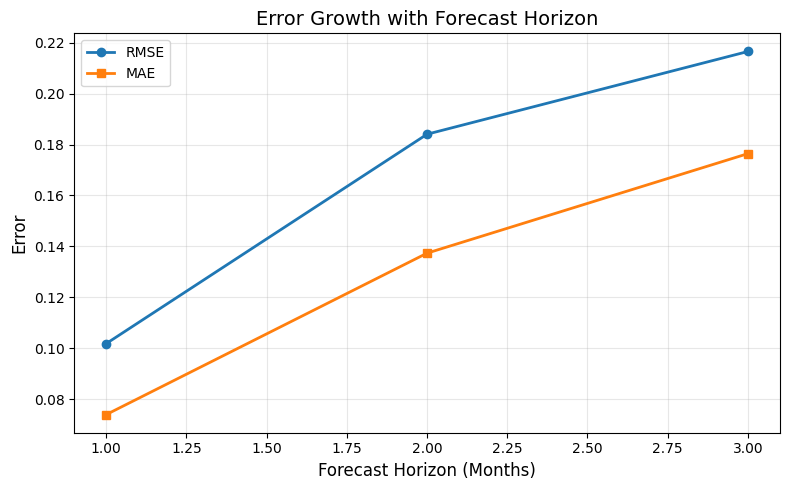

In [17]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Step"], results_df["RMSE"], marker='o', linewidth=2, label="RMSE")
plt.plot(results_df["Step"], results_df["MAE"], marker='s', linewidth=2, label="MAE")

plt.xlabel("Forecast Horizon (Months)", fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title("Error Growth with Forecast Horizon", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("error_growth.png", dpi=300)
plt.show()

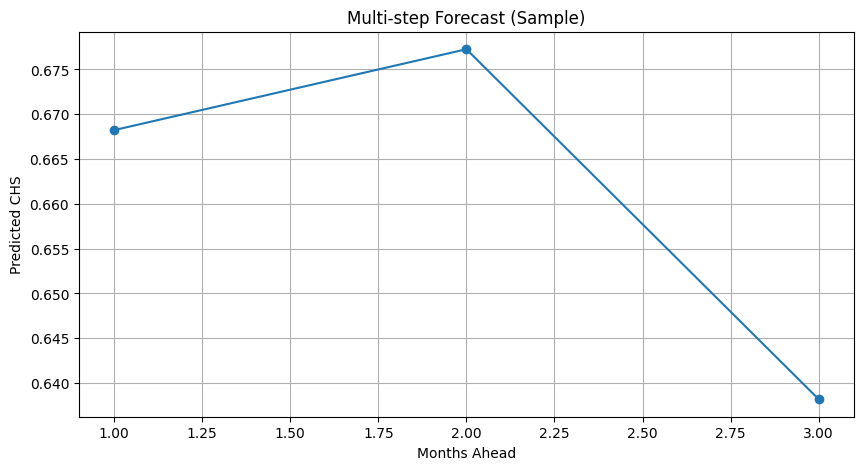

In [16]:
sample_idx = 0

plt.figure(figsize=(10,5))

plt.plot(range(1, N+1), forecast_preds[sample_idx], marker='o')

plt.xlabel("Months Ahead")
plt.ylabel("Predicted CHS")
plt.title("Multi-step Forecast (Sample)")

plt.grid()
plt.show()

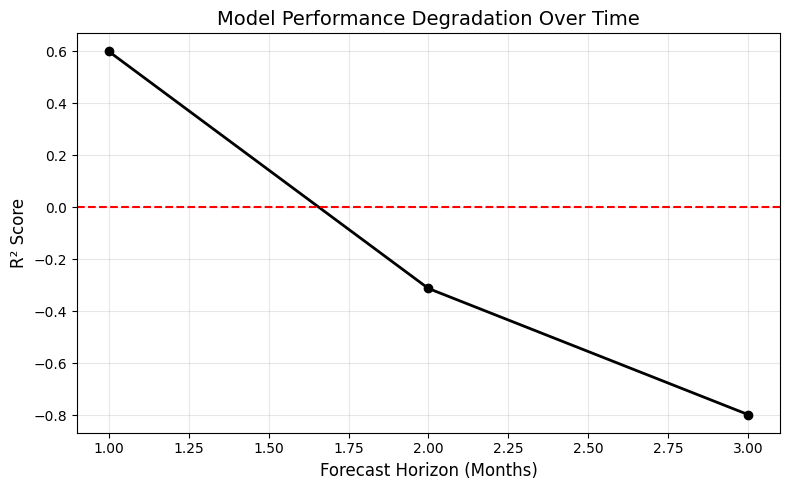

In [18]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Step"], results_df["R2"], marker='o', color='black', linewidth=2)

plt.axhline(0, linestyle='--', color='red')

plt.xlabel("Forecast Horizon (Months)", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title("Model Performance Degradation Over Time", fontsize=14)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("r2_degradation.png", dpi=300)
plt.show()

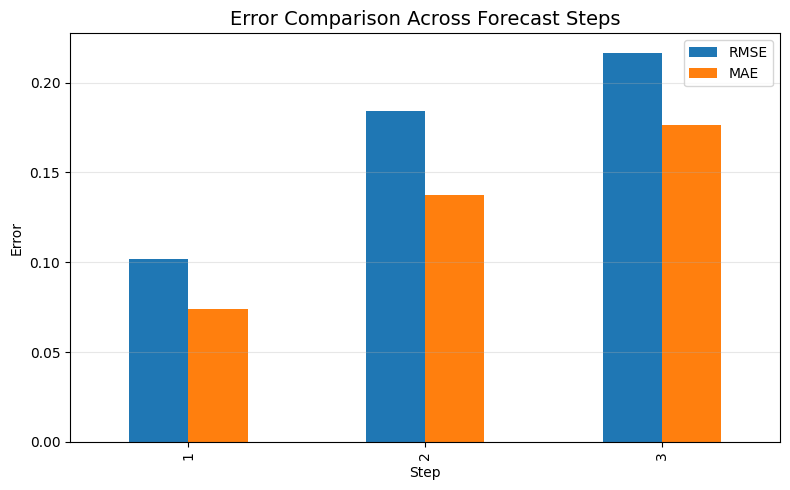

In [19]:
results_df.set_index("Step")[["RMSE","MAE"]].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Error Comparison Across Forecast Steps", fontsize=14)
plt.ylabel("Error")
plt.xlabel("Step")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("bar_error.png", dpi=300)
plt.show()

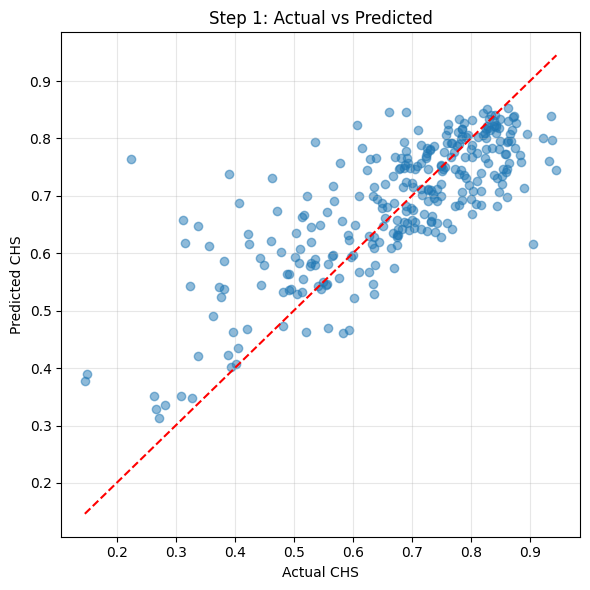

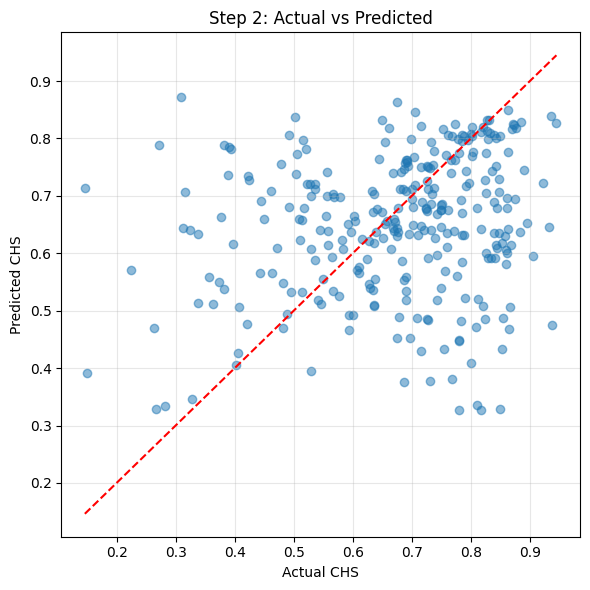

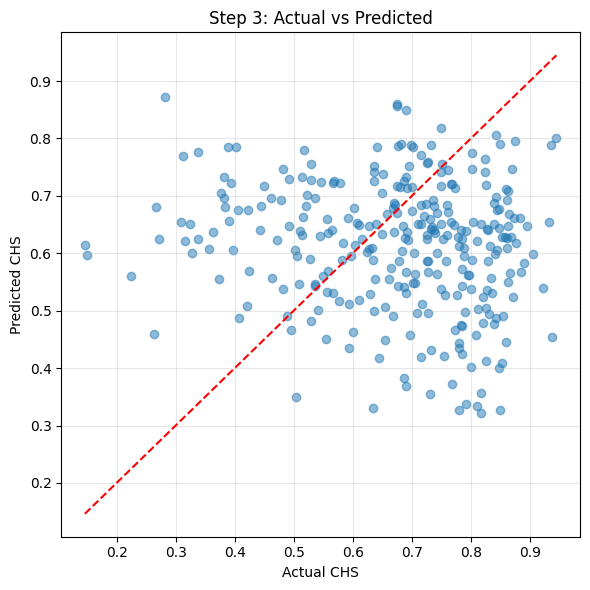

In [20]:
for step in range(3):
    plt.figure(figsize=(6,6))

    y_true = y_test[step:len(y_test)-(3-step-1)]
    y_pred = forecast_preds[:len(y_true), step]

    plt.scatter(y_true, y_pred, alpha=0.5)

    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')

    plt.xlabel("Actual CHS")
    plt.ylabel("Predicted CHS")
    plt.title(f"Step {step+1}: Actual vs Predicted")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"scatter_step_{step+1}.png", dpi=300)
    plt.show()

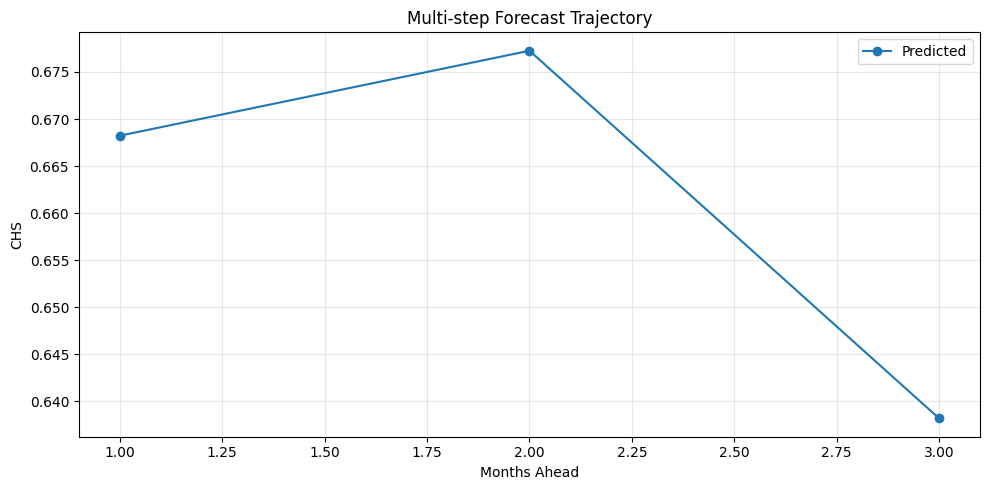

In [21]:
sample = 0

plt.figure(figsize=(10,5))

plt.plot(range(1,4), forecast_preds[sample], marker='o', label="Predicted")

plt.xlabel("Months Ahead")
plt.ylabel("CHS")
plt.title("Multi-step Forecast Trajectory")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("forecast_trajectory.png", dpi=300)
plt.show()